#  Keras — The Easy Button for Neural Networks

**Keras** is a library that makes building neural networks **much simpler**. It works
as a friendly "front door" to powerful engines like TensorFlow.

>  **Simple idea:** If TensorFlow is a car engine, Keras is the steering wheel and pedals —
> it lets you drive powerful AI models without needing to understand every engine part.

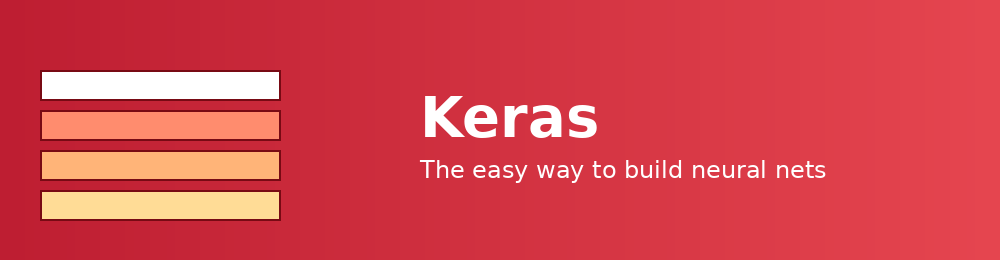


##  History — Where did Keras come from?

- Keras was created by **François Chollet**, a Google engineer, and released in **March 2015**
  — actually a little before TensorFlow's public release!
- The name "Keras" comes from a Greek word (κέρας) meaning **"horn"**, referencing a
  story about dreams passing through gates of horn or ivory — Chollet liked the poetic meaning.
- Originally Keras could work with multiple engines (called "backends") like Theano
  or TensorFlow. Since 2017, Keras became the **official, easy-to-use API built into
  TensorFlow** itself (`tf.keras`), and today Keras 3 can also work with PyTorch and JAX!

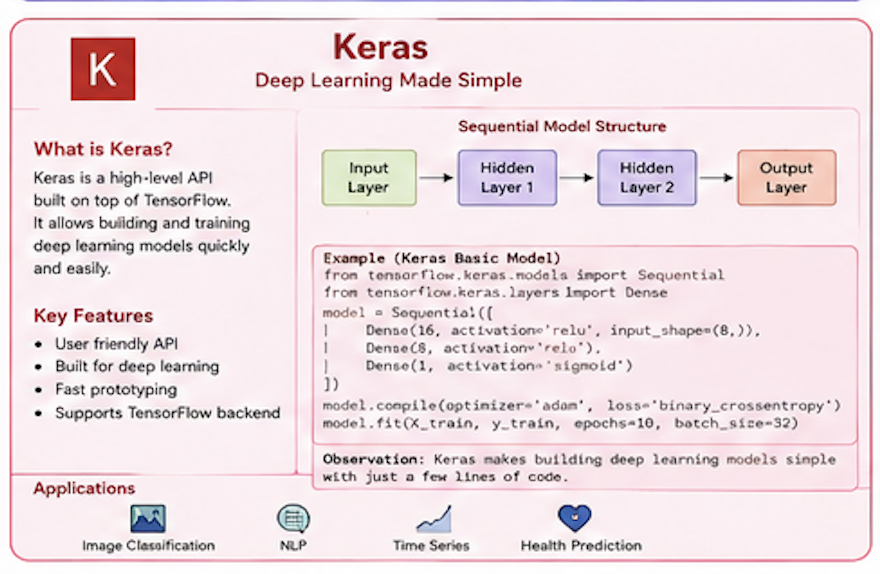

##  Why do we need Keras if we have TensorFlow?

Building neural networks with raw TensorFlow can be complicated, with lots of technical
detail. Keras hides that complexity so **beginners** (like you!) can build powerful models
with very few, easy-to-read lines of code.

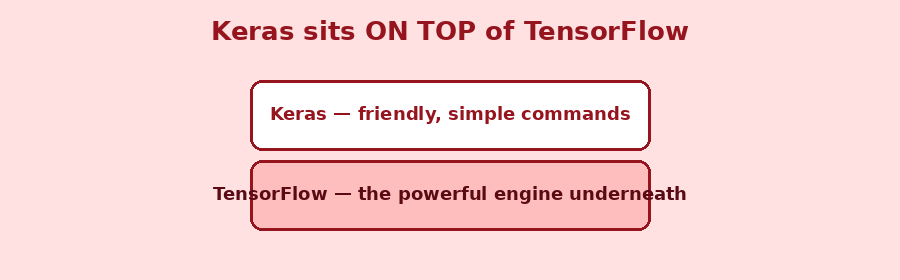


##  Step 1: Import Keras

In [4]:
import tensorflow as tf
from tensorflow import keras
print("Keras is ready! Version:", keras.__version__)

Keras is ready! Version: 3.13.2


###  Step 2: Load a Famous Beginner Dataset — Handwritten Digits (MNIST)
This dataset has 70,000 tiny images of handwritten numbers (0-9). It's the "hello world"
of neural networks!

In [13]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Each image is", x_train.shape[1], "x", x_train.shape[2], "pixels")

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
Each image is 28 x 28 pixels


##  Let's Look at a Digit!

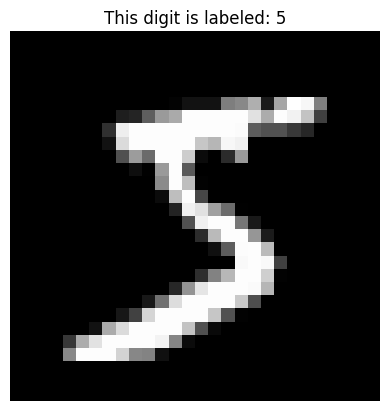

In [6]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap="gray")
plt.title(f"This digit is labeled: {y_train[0]}")
plt.axis("off")
plt.show()

##  Step 3: Prepare the Data
We scale pixel values from 0-255 down to 0-1, which helps the model learn better.

In [7]:
x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0
print("Data is ready for training!")

Data is ready for training!


##  Step 4: Build a Simple Neural Network with Keras

In [8]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),      # unroll the image into a line of numbers
    keras.layers.Dense(128, activation="relu"),       # a "thinking" layer with 128 neurons
    keras.layers.Dense(10, activation="softmax")       # output layer: 10 possible digits (0-9)
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

##  Step 5: Train the Model

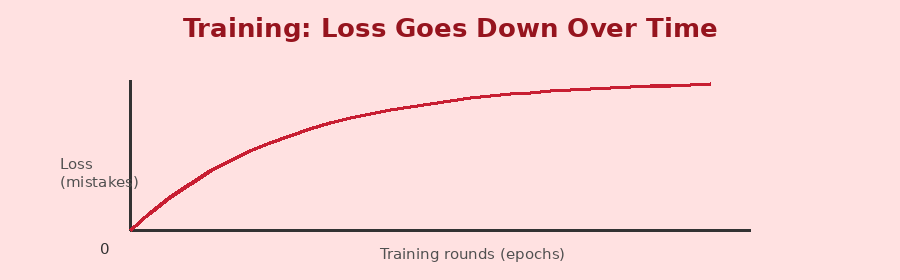


In [9]:
history = model.fit(x_train_scaled, y_train, epochs=5, verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9253 - loss: 0.2601
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9660 - loss: 0.1131
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9768 - loss: 0.0775
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9826 - loss: 0.0580
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9855 - loss: 0.0453


##  Step 6: Test the Model on New Digits

In [10]:
test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f"Accuracy on brand-new test digits: {test_accuracy*100:.1f}%")

Accuracy on brand-new test digits: 97.7%


##  Let's See a Prediction!

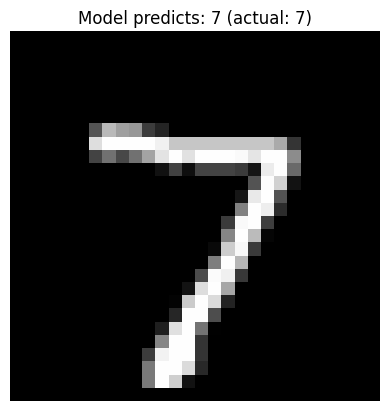

In [11]:
import numpy as np

sample = x_test_scaled[0]
prediction = model.predict(np.array([sample]), verbose=0)
predicted_digit = np.argmax(prediction)

plt.imshow(x_test[0], cmap="gray")
plt.title(f"Model predicts: {predicted_digit} (actual: {y_test[0]})")
plt.axis("off")
plt.show()

##  Mini Challenge
1. Change `epochs=5` to `epochs=2` or `epochs=10` — does accuracy change?
2. Try a different image index, like `x_test_scaled[25]`, and see if the model gets it right.

In [12]:
# Write your code here!

##  Fun Fact
The very same style of model you just built (just bigger and more advanced) is part of
the technology behind things like Face ID on phones and self-driving cars!

##  Summary
- Keras = the easy, friendly way to build neural networks.
- Created by François Chollet in 2015; now built into TensorFlow as `tf.keras`.
- You stack `layers` to build a model, `compile` it, `fit` it, then `evaluate`/`predict`.
- You just built a neural network that recognizes handwritten digits — that's real AI!